<a href="https://colab.research.google.com/github/Pedro4Albuquerque/09-DIS-Disney-Dire-o-de-Volume/blob/main/prova_09_pedro_souza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09: DIS (Disney) | Direção de Volume:
**Alvo (Y):** 1 (Crescente) ou 0 (Decrescente) em relação ao dia anterior.

**Desafio:** Prever se o fechamento atual é influenciado pelo volume da véspera.
## Aluno : Pedro Henrique Albuquerque Souza

# Pipeline 1 | Carregamento dos Dados via API [DIS - Disney]

In [28]:

from typing import List
import requests
import pandas as pd

API_KEY = "YF91FPXACQJ396DA"
SYMBOL = "DIS"

url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={SYMBOL}&outputsize=compact&apikey={API_KEY}'
r = requests.get(url)
data = r.json()

dados = data["Time Series (Daily)"]

base_dis = pd.DataFrame.from_dict(
    dados,
    orient="index"
)

base_dis

,1. open,2. high,3. low,4. close,5. volume
2026-05-08,109.3100,109.3100,107.5400,107.9800,8353835
2026-05-07,109.0500,110.4800,107.0900,108.6600,14309207
2026-05-06,106.5150,109.1400,105.3100,108.0600,23219533
2026-05-05,101.5300,101.7300,100.0600,100.4800,14314678
2026-05-04,102.7400,103.0500,101.2700,101.3100,8400068
...,...,...,...,...,...
2025-12-19,112.3200,113.4780,110.9200,111.2400,21138383
2025-12-18,110.5300,112.8000,110.4200,111.8700,12913867
2025-12-17,111.0600,112.1300,110.4550,110.6300,12142521
2025-12-16,111.2150,112.8499,110.8550,111.6200,15580195


## Blibliotecas de Python

In [29]:
!pip -q install plotly
!pip -q install yellowbrick

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Pipeline 2 | Organização e Limpeza

In [31]:
base_dis.index = pd.to_datetime(base_dis.index)

base_dis = base_dis.rename(columns={
    "1. open": "Open",
    "2. high": "High",
    "3. low": "Low",
    "4. close": "Close",
    "5. volume": "Volume"
})

base_dis = base_dis.astype(float)

base_dis = base_dis.sort_index()

base_dis

,Open,High,Low,Close,Volume
2025-12-15,110.700,111.5500,108.550,110.49,14317985.0
2025-12-16,111.215,112.8499,110.855,111.62,15580195.0
2025-12-17,111.060,112.1300,110.455,110.63,12142521.0
2025-12-18,110.530,112.8000,110.420,111.87,12913867.0
2025-12-19,112.320,113.4780,110.920,111.24,21138383.0
...,...,...,...,...,...
2026-05-04,102.740,103.0500,101.270,101.31,8400068.0
2026-05-05,101.530,101.7300,100.060,100.48,14314678.0
2026-05-06,106.515,109.1400,105.310,108.06,23219533.0
2026-05-07,109.050,110.4800,107.090,108.66,14309207.0


# Pipeline 3 | Análise Exploratória

 Mostra informações gerais da tabela.

In [32]:
base_dis.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2025-12-15 to 2026-05-08
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    100 non-null    float64
 1   High    100 non-null    float64
 2   Low     100 non-null    float64
 3   Close   100 non-null    float64
 4   Volume  100 non-null    float64
dtypes: float64(5)
memory usage: 4.7 KB


 Gera estatísticas automáticas das colunas numéricas.

In [33]:
base_dis.describe()

,Open,High,Low,Close,Volume
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,105.549700,106.743245,104.489575,105.597900,1.082254e+07
std,5.789205,5.850398,5.806473,5.898052,4.999430e+06
min,92.890000,94.190000,92.185000,92.420000,4.606746e+06
25%,101.240000,101.856650,100.195000,101.307500,8.100944e+06
50%,105.005000,106.744950,103.972500,105.245000,9.625417e+06
75%,111.098750,112.507500,110.466250,111.210000,1.203413e+07
max,114.770000,116.030000,114.100000,115.880000,3.777850e+07


## Verifica valores vazios (NaN) na tabela.

In [34]:
base_dis.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


# Pipeline 4 | Visualização de Dados

Nesta etapa serão apresentados gráficos relacionados ao fechamento e volume da ação, permitindo observar padrões e oscilações do mercado.

Fechamento das ações

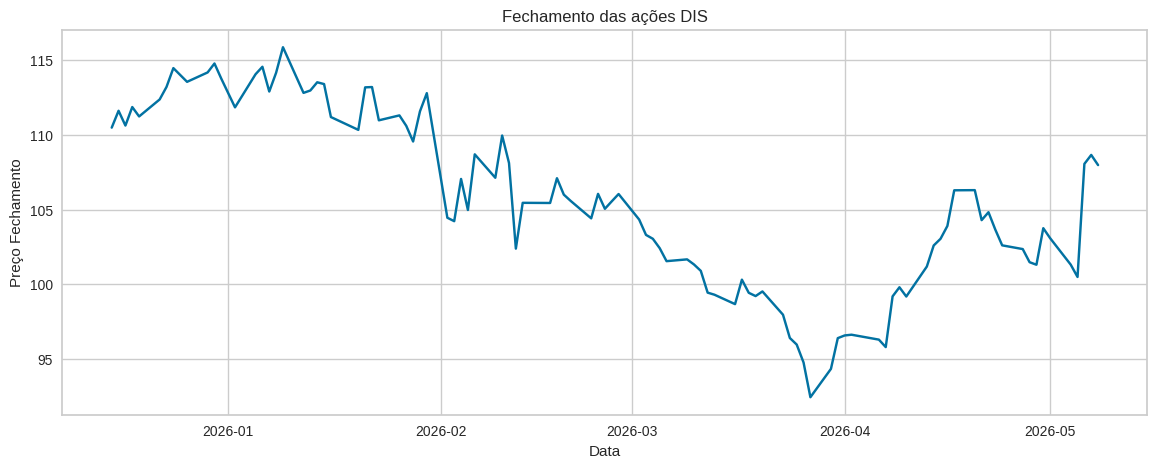

In [35]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Close"])

plt.title("Fechamento das ações DIS")
plt.xlabel("Data")
plt.ylabel("Preço Fechamento")

plt.show()

 Volume negociado

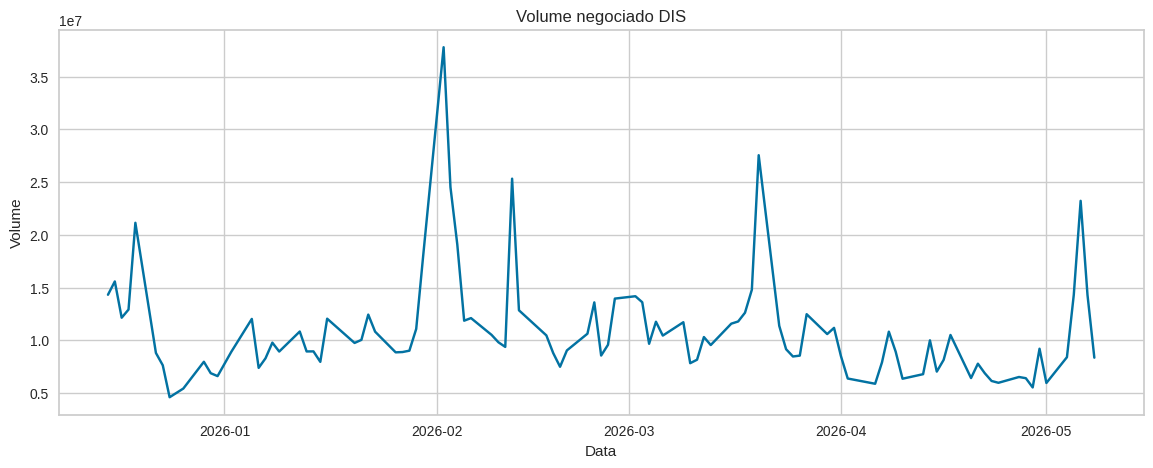

In [36]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Volume"])

plt.title("Volume negociado DIS")
plt.xlabel("Data")
plt.ylabel("Volume")

plt.show()

Correlação

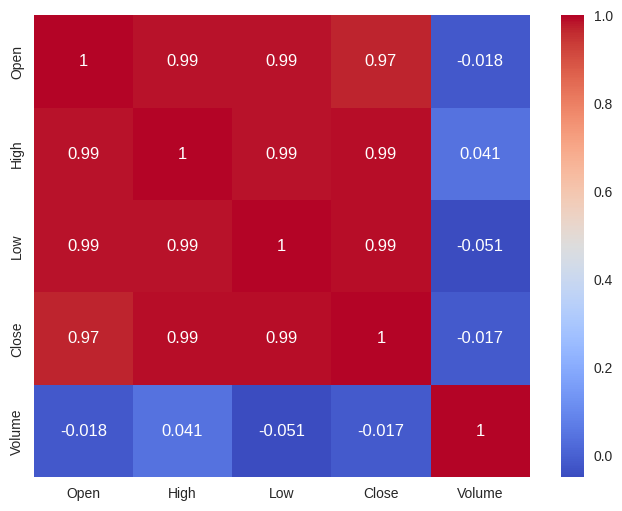

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    base_dis.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Pipeline 5 | Engenharia de Features

Para analisar a influência do volume da véspera, foi criada a variável `volume_anterior` utilizando o método shift().

Também foi criada a variável alvo `direcao`, onde:

- 1 = fechamento crescente
- 0 = fechamento decrescente

 Criação do alvo Y

In [38]:
base_dis["fechamento_anterior"] = base_dis["Close"].shift(1)

base_dis["direcao"] = np.where(
    base_dis["Close"] > base_dis["fechamento_anterior"],
    1,
    0
)

Volume da véspera

In [39]:
base_dis["volume_anterior"] = base_dis["Volume"].shift(1)

Removendo valores nulos

In [40]:
base_dis.dropna(inplace=True)

# Pipeline 6 | Separação X e Y

In [41]:
X_dis = base_dis[
    [
      "volume_anterior"
    ]
].values

Y_dis = base_dis["direcao"].values

# Pipeline 7 | Normalização e Treinamento

In [42]:
from sklearn.model_selection import train_test_split
X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(
    X_dis,
    Y_dis,
    test_size=0.20,
    random_state=0,
    shuffle=False
)


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_treinamento = scaler.fit_transform(X_treinamento)
X_teste = scaler.transform(X_teste)

Treinamento GaussianNB

In [44]:
from sklearn.naive_bayes import GaussianNB

modelo_dis = GaussianNB()

modelo_dis.fit(
    X_treinamento,
    Y_treinamento
)

GaussianNB()

# Pipeline 8 | Previsões e Avaliação

In [45]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [46]:
previsoes = modelo_dis.predict(X_teste)

previsoes

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])


Nesta etapa serão analisadas as métricas de desempenho do modelo, incluindo acurácia, matriz de confusão
e relatório de classificação.

Acurácia

In [47]:
accuracy_score(
    Y_teste,
    previsoes
)

0.55

Matriz de Confusão

In [48]:
confusion_matrix(
    Y_teste,
    previsoes
)

array([[9, 1],
       [8, 2]])

Relatório

In [49]:
print(
    classification_report(
        Y_teste,
        previsoes
    )
)

              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.67      0.20      0.31        10

    accuracy                           0.55        20
   macro avg       0.60      0.55      0.49        20
weighted avg       0.60      0.55      0.49        20



# Pipeline 9 | Yellowbrick

In [50]:
from yellowbrick.classifier import ConfusionMatrix

0.55

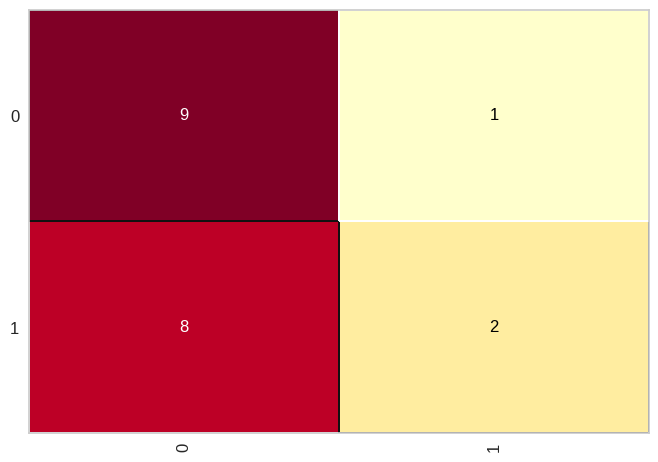

In [51]:
cm_dis = ConfusionMatrix(modelo_dis)

cm_dis.fit(
    X_treinamento,
    Y_treinamento
)

cm_dis.score(
    X_teste,
    Y_teste
)


Distribuição do alvo

<Axes: xlabel='direcao', ylabel='count'>

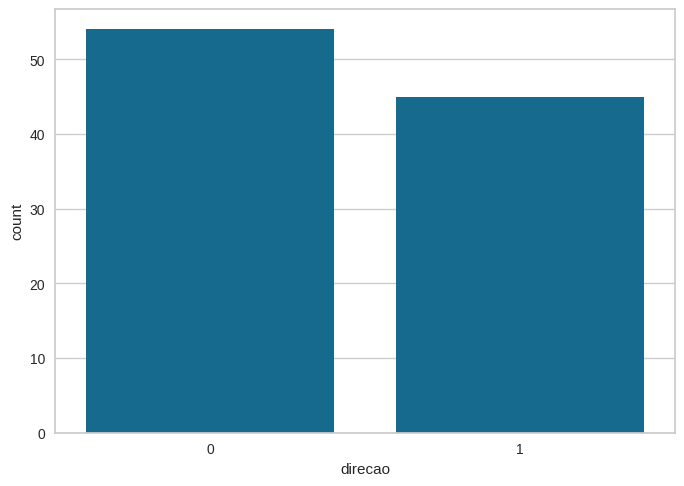

In [52]:
sns.countplot(x=base_dis["direcao"])

Gráfico interativo

In [53]:
grafico = px.line(
    base_dis,
    x=base_dis.index,
    y="Close",
    title="Fechamento DIS"
)

grafico.show()